# Geospatial Python: Vector Data

---

## 0. Set-Up Guide
Before opening your Terminal, Command Prompt, or Powershell:
1. Locate your project folder.
2. Make sure there is a subfolder inside it named `data`
3. Move the [training data](https://drive.google.com/drive/folders/1xw4-USwwN-14UN1fqSBcXkLgjyv0b8l0?usp=drive_link) files into the `data` folder.

Then, open your Terminal, Command Prompt, or Powershell and finish the set-up.

In [ ]:
# Make sure you are in your working directory
cd path/to/geospatial_training_folder

In [ ]:
# Initialize and activate the virtual environment
uv init

In [ ]:
# Install the required packages
uv add jupyterlab pandas numpy geopandas shapely rasterio matplotlib contextily

In [ ]:
# Launch jupyter lab
uv run jupyter lab

---

## 1. Shapely

### 1.1 Introduction to Geometries

In Geographic Information Systems (GIS), vector data represents the world using discrete shapes.

The `shapely` library is the standard Python tool for creating and analyzing these shapes in memory. It is the direct equivalent of `ee.Geometry` in GEE.
- **Point:** A single location defined by an X (Longitude) and Y (Latitude) coordinate.
- **LineString:** A sequence of connected points (e.g., a road or river)
- **Polygon:** A closed shape representing an area (e.g., a farm plot or barangay boundary)

### 1.2 Creating Basic Shapes

In [15]:
from shapely.geometry import Point, LineString, Polygon

In [16]:
# 1. Point (Longitude, Latitude)
farm_location = Point(121.0, 14.5)
print("Point created:", farm_location)

Point created: POINT (121 14.5)


In [17]:
# 2. LineString (Requires a list of coordinate tuples)
irrigation_canal = LineString([(121.0, 14.5), (121.1, 14.6), (121.2, 14.5)])
print("Line created:", irrigation_canal)

Line created: LINESTRING (121 14.5, 121.1 14.6, 121.2 14.5)


In [18]:
# 3. Polygon (Requires a list of coordinate tuples that close a shape)
farm_boundary = Polygon([
    (121.0, 14.5), 
    (121.0, 14.6), 
    (121.1, 14.6), 
    (121.1, 14.5), 
    (121.0, 14.5) # The last point must match the first to close the polygon
])
print("Polygon created:", farm_boundary)

Polygon created: POLYGON ((121 14.5, 121 14.6, 121.1 14.6, 121.1 14.5, 121 14.5))


### 1.3 Check-In Exercise

**Tasks**
1. Create a `Point` representing an imaginary market location at longitude `123.5` and latitude `10.2`. Assign it to a variable named `market_pt`
2. Create a `Polygon` representing a triangular farm plot. Assign it to `triangle_farm`
3. Print both variables.

In [ ]:
# Write code here


In [31]:
# Solution

# Shapely always takes coordinates in (Longitude, Latitude) order.
# To make a valid polygon, the first and last coordinate pair must be exactly the same

from shapely.geometry import Point, Polygon

# Task 1: Create the market Point
market_pt = Point(123.5, 10.2)

# Task 2: Create a triangular farm Polygon
# A triangle requires 3 corners, plus a 4th point identical to the 1st to close it
triangle_farm = Polygon([
    (121.0, 14.5), # Point 1
    (121.1, 14.5), # Point 2
    (121.05, 14.6),# Point 3
    (121.0, 14.5)  # Back to Point 1
])

# Task 3: Print both variables
print("Market Point:", market_pt)
print("Triangular Farm:", triangle_farm)

Market Point: POINT (123.5 10.2)
Triangular Farm: POLYGON ((121 14.5, 121.1 14.5, 121.05 14.6, 121 14.5))


---

## 2. GeoPandas

### 2.1 What is a GeoDataFrame?
While `shapely` handles the math of the shapes, it does not store attribute data (like crop type, farmer name, or yield).

`geopandas` extends the standard `pandas` library. A `GeoDataFrame`is simply a standard `DataFrame` that contains a column named `geometry`. This columns holds the `shapely` objects.

### 2.2 Creating a GeoDataFrame

In [19]:
import pandas as pd
import geopandas as gpd

# Standard Pandas DataFrame
data = {
    'farm_id': [101, 102],
    'crop_type': ['Rice', 'Corn'],
    'latitude': [14.1, 14.2],
    'longitude': [121.5, 121.6]
}
df = pd.DataFrame(data)

# Convert coordinates to Shapely Points
geometries = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]

# Create the GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=geometries)

# Set the Coordinate Reference System (CRS) to standard WGS84
gdf.set_crs(epsg=4326, inplace=True)

print(gdf.head())

   farm_id crop_type  latitude  longitude            geometry
0      101      Rice      14.1      121.5  POINT (121.5 14.1)
1      102      Corn      14.2      121.6  POINT (121.6 14.2)


### 2.3 Check-In Exercise

**Tasks**
1. Add a third farm to the `data` dictionary above (Farm 103, growing Mango, at Lat 14.3 and Lon 121.7)
2. Re-run the geometry creation and create a new `GeoDataFrame` named `gdf_updated`
3. Print the Coordinate Reference System (`crs`) of your new `gdf_updated`

In [ ]:
# Write code here


In [41]:
# Solution

# To add a new farm, update the original dictionary lists.
# Then, repeat the list comprehension process to generate new Point geometries
# and bind to a new GeoDataFrame.

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Task 1: Update the data dictionary with Farm 103 (Mango)
data = {
    'farm_id': [101, 102, 103],
    'crop_type': ['Rice', 'Corn', 'Mango'],
    'latitude': [14.1, 14.2, 14.3],
    'longitude': [121.5, 121.6, 121.7]
}
df = pd.DataFrame(data)

# Task 2: Re-run the geometry creation and make gdf_updated
geometries = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]
gdf_updated = gpd.GeoDataFrame(df, geometry=geometries)

# Set the CRS to WGS84
gdf_updated.set_crs(epsg=4326, inplace=True)

# Task 3: Print the CRS
print("The CRS is:")
print(gdf_updated.crs)

The CRS is:
EPSG:4326


---

## 3. Processing Real Survey Data

### 3.1 Loading the PSA Agricultural Survey

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
from shapely.validation import make_valid

# Load the RAW survey data
raw_survey_df = pd.read_csv("data/PSA Agricultural Survey.csv")

### 3.2 Extracting Points `crop_location`

In [4]:
# Filter out rows missing point coordinate data
df_points = raw_survey_df.dropna(subset=['crop_location-Latitude', 'crop_location-Longitude']).copy()

# Generate point geometries
survey_points = [
    Point(xy) for xy in zip(df_points['crop_location-Longitude'], df_points['crop_location-Latitude'])
]

# Create the main points GeoDataFrame
gdf_survey_points = gpd.GeoDataFrame(df_points, geometry=survey_points)
gdf_survey_points.set_crs(epsg=4326, inplace=True)

print(f"Successfully loaded {len(gdf_survey_points)} farm point locations.")

Successfully loaded 16 farm point locations.


### 3.2 Parsing ODK Polygon Strings `shape_input`

The survey also includes farm boundaries in the `shape_input` column. These are stored as continuous text strings separated by semicolons. We will parse these strings into `Polygon` objects.

In [5]:
def parse_odk_shape(shape_str):
    """Safely converts an ODK text string into a valid Shapely Polygon."""
    if not isinstance(shape_str, str):
        return None
        
    coords = []
    points_list = shape_str.split(';')
    
    for pt in points_list:
        parts = pt.split() # Safely splits by any spaces, ignoring messy formatting
        if len(parts) >= 2:
            try:
                lat = float(parts[0])
                lon = float(parts[1])
                coords.append((lon, lat)) 
            except ValueError:
                continue
                
    if len(coords) >= 3:
        poly = Polygon(coords)
        return make_valid(poly) # Fixes self-intersecting polygons
        
    return None

# Filter out rows missing polygon shape data
df_shapes = raw_survey_df.dropna(subset=['shape_input']).copy()

# Apply the safe parsing function
df_shapes['geometry'] = df_shapes['shape_input'].apply(parse_odk_shape)

# Drop rows that failed to form a valid polygon
df_shapes = df_shapes.dropna(subset=['geometry'])
gdf_survey_polygons = gpd.GeoDataFrame(df_shapes, geometry='geometry')
gdf_survey_polygons.set_crs(epsg=4326, inplace=True)

print(f"Successfully extracted {len(gdf_survey_polygons)} farm polygons.")

Successfully extracted 66 farm polygons.


### 3.3 Check-In Exercise

**Tasks**
1. Check the column names of `gdf_survey points`.
2. Create a subset GeoDataFrame called `gdf_seaweed_points` that only contains rows where the `crop_type` column equals `"seaweed"`
3. Print the number of rows in `gdf_seaweed_points` using the `len()` function.

In [ ]:
# Write code here

In [43]:
# Solution

# Task 1: Check the column names
print("Column Names:")
print(gdf_survey_points.columns.tolist())

# Task 2: Filter for 'seaweed'
gdf_seaweed_points = gdf_survey_points[gdf_survey_points['crop_type'] == 'seaweed'].copy()

# Task 3: Print the number of rows
print(f"\nNumber of Seaweed farms: {len(gdf_seaweed_points)}")

Column Names:
['Date', 'crop_type', 'mango_stage', 'calamansi_stage', 'abaca_stage', 'sweetpotato_stage', 'eggplant_stage', 'tomato_stage', 'tobacco_stage', 'seaweed_stage', 'primary_crop', 'primary_crop_text', 'crop_condition', 'other_crop_condition', 'mango_variety', 'other_mango_variety', 'calamansi_variety', 'other_calamansi_variety', 'abaca_variety', 'other_abaca_variety', 'sweetpotato_variety', 'other_sweetpotato_variety', 'eggplant_variety', 'other_eggplant_variety', 'tomato_variety', 'other_tomato_variety', 'tobacco_variety', 'other_tobacco_variety', 'seaweed_variety', 'other_seaweed_variety', 'main_crop', 'main_crop_mango', 'other_main_crop_mango', 'main_crop_all', 'other_main_crop_all', 'date_planted', 'other_crop_rotation', 'date_other_crop_rotation', 'average', 'farming_method', 'seaweed_farm', 'aquaculture_integrated', 'purpose_integration', 'other_purpose', 'other_aquaculture_integrated', 'application_fertilizer', 'cropping_period-date_planted3_start', 'cropping_period-da

---

## 4. Visualization and Exporting

### 4.1 Static Mapping wit Contextily
`GeoPandas` uses `matplotlib` internally. Calling `.plot()` on a GeoDataFrame renders the geometries instantly. 

In [6]:
# Calculate the area of each polygon in square meters
# Temporarily convert to Web Mercator EPSG:3857 because EPSG:4326 measures in degrees, not meters
polygon_areas = gdf_survey_polygons.to_crs(epsg=3857).area

# Filter the dataset to only keep reasonably sized farm plots
valid_farms = gdf_survey_polygons[polygon_areas < 100000].copy()

print(f"Removed {len(gdf_survey_polygons) - len(valid_farms)} outlier polygons.")

Removed 4 outlier polygons.


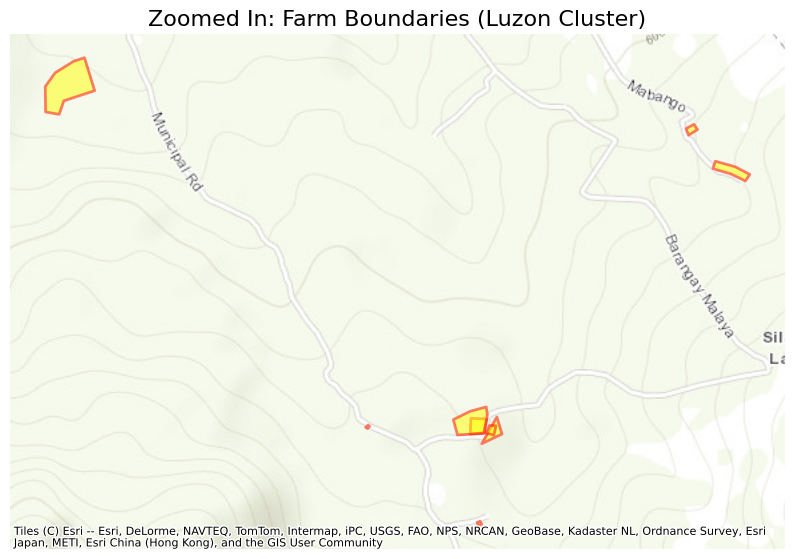

In [7]:
import matplotlib.pyplot as plt
import contextily as cx

# Spatial Filtering using .cx (Coordinate Indexer)
# The syntax is .cx[min_longitude : max_longitude, min_latitude : max_latitude]
# Keep all longitudes, but only keep latitudes from 13 and above
luzon_farms = valid_farms.cx[:, 13:].copy()

# Reproject to Web Mercator (EPSG:3857) to match the basemap
plot_luzon_farms = luzon_farms.to_crs(epsg=3857)

# Initialize the plot canvas
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the Luzon cluster
plot_luzon_farms.plot(ax=ax, color='yellow', edgecolor='red', linewidth=2, alpha=0.5)

# Add a Satellite Basemap
cx.add_basemap(ax, source=cx.providers.Esri.WorldTopoMap)

# Formatting
plt.title("Zoomed In: Farm Boundaries (Luzon Cluster)", fontsize=16)
ax.set_axis_off() 

plt.show()

### 4.2 Exporting

In [9]:
import os

os.makedirs("exports", exist_ok=True)

# Rename 'SubmissionDate' to 'Date' (4 characters) for Shapefile
gdf_survey_points = gdf_survey_points.rename(columns={'SubmissionDate': 'Date'})
valid_farms = valid_farms.rename(columns={'SubmissionDate': 'Date'})

# Select columns to export
export_cols = ['Date', 'crop_type', 'geometry']

# Export the Points
gdf_survey_points[export_cols].to_file("exports/ODK_geopoints.shp")

# Filter the Polygons to remove collapsed LineStrings
strict_polygons = valid_farms[valid_farms.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()
print(f"Dropped {len(valid_farms) - len(strict_polygons)} collapsed geometries.")

# Export the strictly validated Polygons
strict_polygons[export_cols].to_file("exports/ODK_geoshape.shp")

print("Cleaned datasets successfully exported to the /exports directory.")

Dropped 3 collapsed geometries.
Cleaned datasets successfully exported to the /exports directory.


---

## 5. Long Exercise
Let's simulate a real-world data cleaning and spatial processing workflow.

The Department of Agriculture wants to establish a **50-meter agricultural "buffer zone"** around the boundaries of all **Tomato** farms in Luzon.

**Tasks**
1. Starting with the `strict_polygons` GeoDataFrame we created, filter the data to only keep rows where `crop_type` is `"tomato"`. Store this in `tomato_gdf`
2. Zoom in on the northern part by using the `.cx` spatial indexer on `tomato_gdf` to only keep farms with a Latitude of 13 and above. Store this in `luzon_tomatoes`
3. Reproject `luzon_tomatoes` into Web Mercator (`epsg=3857`). Store it in `luzon_meters`
4. Create a new column called `buffer_geom` by using `.buffer(50)` on the geometry column. 
5. Replace the active geometry of `luzon_meters` by assigning the `buffer_geom` to the active geometry using `.set_geometry()`
6. Create a `matplotlib` plot showing the buffered tomato areas. Color them green.
7. Add the `Esri.WorldImagery` satellite basemap using `contextily`

In [47]:
# Write code here

# Task 1: Filter for tomatoes


# Task 2: Zoom in on the Luzon cluster (Latitude > 13)


# Task 3: Reproject to meters, buffer by 50, and set geometry


# Task 4: Plot the buffered areas with a satellite basemap


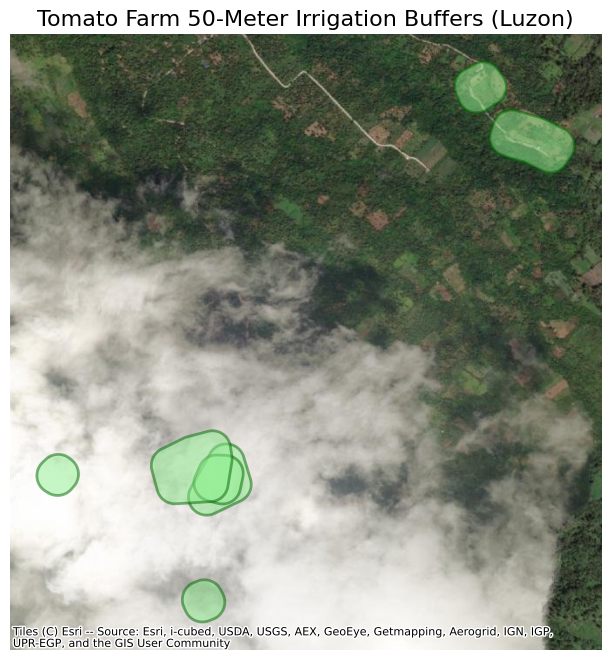

In [10]:
# Solution

import matplotlib.pyplot as plt
import contextily as cx

# Task 1: Tabular Filter
tomato_gdf = strict_polygons[strict_polygons['crop_type'] == 'tomato'].copy()

# Task 2: Spatial Filter
luzon_tomatoes = tomato_gdf.cx[:, 13:].copy()

# Task 3: Buffer in Meters

# Project to EPSG:3857 (meters)
luzon_meters = luzon_tomatoes.to_crs(epsg=3857)

# Buffer by 50 meters
luzon_meters['buffer_geom'] = luzon_meters.geometry.buffer(50)

# Change the active geometry
luzon_meters = luzon_meters.set_geometry('buffer_geom')

# Task 4: Visualization
fig, ax = plt.subplots(figsize=(10, 8))
luzon_meters.plot(ax=ax, color='lightgreen', edgecolor='darkgreen', linewidth=2, alpha=0.5)

# Add basemap
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)

plt.title("Tomato Farm 50-Meter Irrigation Buffers (Luzon)", fontsize=16)
ax.set_axis_off() 
plt.show()

---